<a href="https://colab.research.google.com/github/muhammad-usman-tech/data-analysis-tasks/blob/main/lab_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

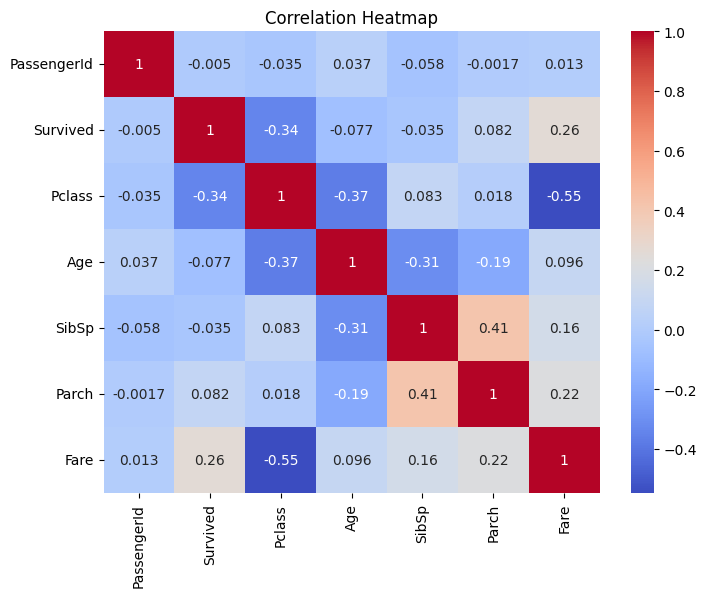

LEVEL 1 — Overall Survival Rate:
38.4%

LEVEL 2 — Survival by Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

LEVEL 3 — Survival by Class AND Gender:
Pclass  Sex   
1       female    96.8
        male      36.9
2       female    92.1
        male      15.7
3       female    50.0
        male      13.5
Name: Survived, dtype: float64

LEVEL 4 — Survival by Class, Gender AND Age Group:
Pclass  Sex     Age_Group  
1       female  Child           90.9
                Young Adult     97.2
                Middle Age      97.2
                Senior         100.0
        male    Child           80.0
                Young Adult     50.0
                Middle Age      37.0
                Senior           8.3
2       female  Child          100.0
                Young Adult     92.5
                Middle Age      85.0
                Senior           NaN
        male    Child           60.0
                Young Adult      7.4
                Middle Age       3.7
   

/tmp/ipykernel_8695/2748528347.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Pclass','Sex','Age_Group'])['Survived'].mean().mul(100).round(1))


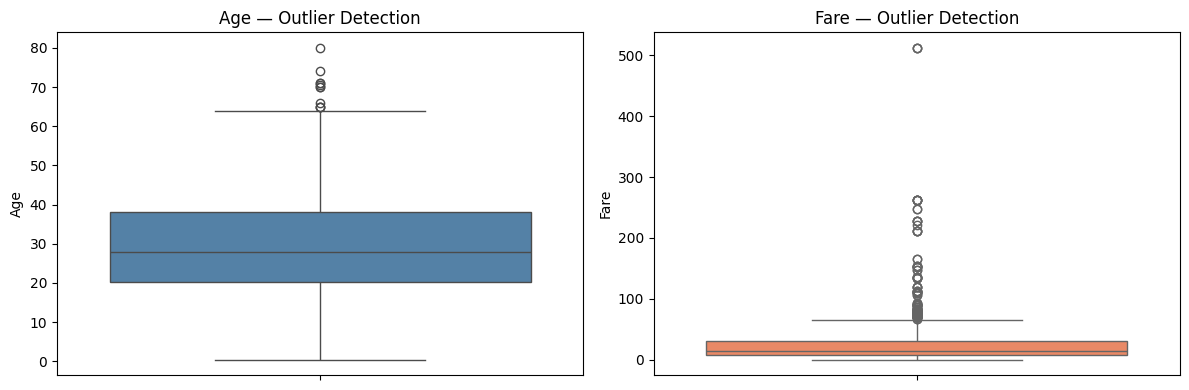


Z-SCORE METHOD:
Age outliers (Z>3): 7
                                     Name   Age  Age_Zscore
96              Goldschmidt, Mr. George B  71.0    3.178283
116                  Connors, Mr. Patrick  70.5    3.139805
493               Artagaveytia, Mr. Ramon  71.0    3.178283
630  Barkworth, Mr. Algernon Henry Wilson  80.0    3.870872
672           Mitchell, Mr. Henry Michael  70.0    3.101328

Fare outliers (Z>3): 20
                                                Name      Fare  Fare_Zscore
27                    Fortune, Mr. Charles Alexander  263.0000     4.647001
88                        Fortune, Miss. Mabel Helen  263.0000     4.647001
118                         Baxter, Mr. Quigg Edmond  247.5208     4.335332
258                                 Ward, Miss. Anna  512.3292     9.667167
299  Baxter, Mrs. James (Helene DeLaudeniere Chaput)  247.5208     4.335332

IQR METHOD:

Age IQR Analysis:
Q1: 20.125, Q3: 38.0, IQR: 17.875
Lower limit: -6.6875, Upper limit: 64.8125
Outliers fo

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('Titanic-Dataset.csv')
df.head()
# df.shape
# df.info()
df.isnull().sum()
# df.describe()
df=df.drop(columns='Cabin')

corr = df.corr(numeric_only=True)
corr
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

from scipy import stats

# =====================
# STEP 5 — DATA DRILLING
# Topic: Data Drilling
# =====================

# First add Age Group column for drilling
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 35, 60, 100],
    labels=['Child', 'Young Adult', 'Middle Age', 'Senior']
)

# Level 1 — Overall survival rate
print("LEVEL 1 — Overall Survival Rate:")
print(f"{df['Survived'].mean()*100:.1f}%")

# Level 2 — Drill down by Class
print("\nLEVEL 2 — Survival by Class:")
print(df.groupby('Pclass')['Survived'].mean().mul(100).round(1))

# Level 3 — Drill down by Class AND Gender
print("\nLEVEL 3 — Survival by Class AND Gender:")
print(df.groupby(['Pclass','Sex'])['Survived'].mean().mul(100).round(1))

# Level 4 — Drill down by Class AND Gender AND Age Group
print("\nLEVEL 4 — Survival by Class, Gender AND Age Group:")
print(df.groupby(['Pclass','Sex','Age_Group'])['Survived'].mean().mul(100).round(1))

# Fare drilling
print("\nFARE DRILLING — By Class:")
print(df.groupby('Pclass')['Fare'].agg(['mean','median','min','max']).round(2))

print("\nFARE DRILLING — By Class AND Embarkation:")
print(df.groupby(['Pclass','Embarked'])['Fare'].mean().round(2))

# =====================
# STEP 6 — OUTLIER DETECTION
# Topic: Data Mining
# =====================

print("=" * 50)
print("OUTLIER DETECTION")
print("=" * 50)

# --- Method 1 — Box Plot ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='steelblue')
plt.title('Age — Outlier Detection')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='coral')
plt.title('Fare — Outlier Detection')

plt.tight_layout()
plt.show()

# --- Method 2 — Z-Score ---
print("\nZ-SCORE METHOD:")
df['Age_Zscore'] = np.abs(stats.zscore(df['Age'].fillna(df['Age'].mean())))
df['Fare_Zscore'] = np.abs(stats.zscore(df['Fare']))

age_outliers = df[df['Age_Zscore'] > 3]
fare_outliers = df[df['Fare_Zscore'] > 3]

print(f"Age outliers (Z>3): {len(age_outliers)}")
print(age_outliers[['Name', 'Age', 'Age_Zscore']].head())

print(f"\nFare outliers (Z>3): {len(fare_outliers)}")
print(fare_outliers[['Name', 'Fare', 'Fare_Zscore']].head())

# --- Method 3 — IQR Method ---
print("\nIQR METHOD:")

# For Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

print(f"\nAge IQR Analysis:")
print(f"Q1: {Q1_age}, Q3: {Q3_age}, IQR: {IQR_age}")
print(f"Lower limit: {lower_age}, Upper limit: {upper_age}")
age_iqr_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)]
print(f"Outliers found: {len(age_iqr_outliers)}")

# For Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

print(f"\nFare IQR Analysis:")
print(f"Q1: {Q1_fare}, Q3: {Q3_fare}, IQR: {IQR_fare}")
print(f"Lower limit: {lower_fare:.2f}, Upper limit: {upper_fare:.2f}")
fare_iqr_outliers = df[(df['Fare'] < lower_fare) | (df['Fare'] > upper_fare)]
print(f"Outliers found: {len(fare_iqr_outliers)}")
print("\nTop fare outliers:")
print(fare_iqr_outliers[['Name', 'Pclass', 'Fare']].sort_values('Fare', ascending=False).head())

In [15]:
# =====================
# STEP 8 — ANOMALY DETECTION
# Topic: Data Mining
# =====================

print("=" * 50)
print("ANOMALY AND PATTERN DETECTION")
print("=" * 50)

# --- 1. Duplicates ---
print("\n1. DUPLICATE DETECTION:")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Check duplicate ticket numbers
dup_tickets = df[df.duplicated(subset=['Ticket'], keep=False)]
print(f"Passengers sharing same ticket: {len(dup_tickets)}")
print(dup_tickets[['Name', 'Ticket', 'Fare', 'Pclass']].head(6))

# --- 2. Rare Values ---
print("\n2. RARE VALUES DETECTION:")

# Rare embarkation ports
print("\nEmbarkation value counts:")
print(df['Embarked'].value_counts())
print(f"Missing Embarked: {df['Embarked'].isnull().sum()}")

# Rare survival combinations
print("\nSex value counts:")
print(df['Sex'].value_counts())

# --- 3. Impossible Combinations ---
print("\n3. IMPOSSIBLE/SUSPICIOUS COMBINATIONS:")

# Zero fare in 1st class
zero_fare_1st = df[(df['Fare'] == 0) & (df['Pclass'] == 1)]
print(f"\n1st class passengers with zero fare: {len(zero_fare_1st)}")
if len(zero_fare_1st) > 0:
    print(zero_fare_1st[['Name', 'Pclass', 'Fare', 'Embarked']])

# Zero fare overall
zero_fare = df[df['Fare'] == 0]
print(f"\nAll zero fare passengers: {len(zero_fare)}")
print(zero_fare[['Name', 'Pclass', 'Fare']].head())

# Very young alone — child travelling alone
child_alone = df[
    (df['Age'] < 10) &
    (df['SibSp'] == 0) &
    (df['Parch'] == 0)
]
print(f"\nChildren under 10 travelling alone: {len(child_alone)}")
if len(child_alone) > 0:
    print(child_alone[['Name', 'Age', 'SibSp', 'Parch', 'Survived']])

# --- 4. Pattern Detection ---
print("\n4. PATTERN DETECTION:")

# Survival pattern — families vs alone
df['Family_Size'] = df['SibSp'] + df['Parch']
df['Is_Alone'] = df['Family_Size'] == 0

alone_survival = df.groupby('Is_Alone')['Survived'].mean() * 100
print("\nSurvival rate — Alone vs With Family:")
print(alone_survival.round(1))

# Fare pattern — zero fare passengers
print("\nZero fare survival rate:")
print(df[df['Fare'] == 0]['Survived'].mean())

print("\nNormal fare survival rate:")
print(df[df['Fare'] > 0]['Survived'].mean())

ANOMALY AND PATTERN DETECTION

1. DUPLICATE DETECTION:
Total duplicate rows: 0
Passengers sharing same ticket: 344
                                                 Name   Ticket     Fare  \
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)   113803  53.1000   
7                      Palsson, Master. Gosta Leonard   349909  21.0750   
8   Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)   347742  11.1333   
9                 Nasser, Mrs. Nicholas (Adele Achem)   237736  30.0708   
10                    Sandstrom, Miss. Marguerite Rut  PP 9549  16.7000   
13                        Andersson, Mr. Anders Johan   347082  31.2750   

    Pclass  
3        1  
7        3  
8        3  
9        2  
10       3  
13       3  

2. RARE VALUES DETECTION:

Embarkation value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Missing Embarked: 2

Sex value counts:
Sex
male      577
female    314
Name: count, dtype: int64

3. IMPOSSIBLE/SUSPICIOUS COMBINATIONS:

1st class pass